In [5]:
"""
OBJECTIF DU PROJET

Ce projet vise à analyser des logs réseau issus du dataset CIC-DDoS2019
afin d’identifier des comportements anormaux caractéristiques des
attaques DrDoS (Distributed Reflection Denial of Service).

Les objectifs sont :

1. Charger et nettoyer un dataset de trafic réseau réel
2. Effectuer une analyse statistique du trafic
3. Identifier les caractéristiques des attaques
4. Détecter les anomalies dans le trafic réseau
5. Identifier les IP potentiellement malveillantes
6. Visualiser les comportements suspects
7. Appliquer un algorithme simple de Machine Learning
8. Générer un rapport de cybersécurité automatisé

Ce type d’analyse constitue une première étape vers des mécanismes
de détection d’attaques adaptés aux architectures SDN et aux réseaux 6G.
"""

'\nOBJECTIF DU PROJET\n\nCe projet vise à analyser des logs réseau issus du dataset CIC-DDoS2019\nafin d’identifier des comportements anormaux caractéristiques des\nattaques DrDoS (Distributed Reflection Denial of Service).\n\nLes objectifs sont :\n\n1. Charger et nettoyer un dataset de trafic réseau réel\n2. Effectuer une analyse statistique du trafic\n3. Identifier les caractéristiques des attaques\n4. Détecter les anomalies dans le trafic réseau\n5. Identifier les IP potentiellement malveillantes\n6. Visualiser les comportements suspects\n7. Appliquer un algorithme simple de Machine Learning\n8. Générer un rapport de cybersécurité automatisé\n\nCe type d’analyse constitue une première étape vers des mécanismes\nde détection d’attaques adaptés aux architectures SDN et aux réseaux 6G.\n'

In [6]:
"""
IMPORT DES LIBRAIRIES

Nous utilisons des bibliothèques Python standards
pour l'analyse de données et la cybersécurité.

pandas  : manipulation des données
numpy   : calculs numériques
matplotlib : visualisation
seaborn : visualisation avancée
sklearn : détection d’anomalies (machine learning)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [7]:
"""
CHARGEMENT DU DATASET

Nous utilisons le fichier DrDoS_DNS.csv provenant du dataset
CIC-DDoS2019 développé par l'Université du New Brunswick.

Ce dataset contient du trafic réseau normal et des attaques
DrDoS DNS.
"""

file_path = "DrDoS_DNS.csv"

df = pd.read_csv(file_path)

# suppression des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

print("Dimensions du dataset :", df.shape)

df.head()

C:\Users\Hmada\AppData\Local\Temp\ipykernel_24156\2252618216.py:13: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dimensions du dataset : (5074413, 88)


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,425,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS
1,430,172.16.0.5-192.168.50.1-60495-634-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,DrDoS_DNS
2,1654,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS
3,2927,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS
4,694,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,DrDoS_DNS


In [8]:
"""
EXPLORATION DU DATASET

Cette étape permet d'identifier les variables disponibles
dans les logs réseau.
"""

for col in df.columns:
    print(col)

Unnamed: 0
Flow ID
Source IP
Source Port
Destination IP
Destination Port
Protocol
Timestamp
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size


In [9]:
"""
NETTOYAGE DES DONNÉES

Les datasets réseau contiennent souvent :

- valeurs infinies
- valeurs manquantes
- erreurs de capture

Nous supprimons ces valeurs pour éviter les erreurs
dans l'analyse statistique.
"""

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(inplace=True)

print("Dataset après nettoyage :", df.shape)

Dataset après nettoyage : (4912019, 88)


In [10]:
"""
SÉLECTION DES VARIABLES

Nous sélectionnons les caractéristiques les plus
pertinentes pour détecter les attaques DoS/DDoS.

Flow Duration        : durée de la communication
Total Fwd Packets    : paquets envoyés
Total Backward Packets : paquets reçus
Flow Bytes/s         : débit en bytes
Flow Packets/s       : débit en paquets
"""

features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

df_features = df[features]

df_features.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s
0,28415,97,0,1.502024e+06,3413.689952
1,2,2,0,4.400000e+08,1000000.000000
2,48549,200,0,1.812602e+06,4119.549321
3,48337,200,0,1.820552e+06,4137.617146
4,32026,200,0,2.747767e+06,6244.925998


In [11]:
"""
ANALYSE STATISTIQUE

Cette étape permet d'observer :

- moyenne du trafic
- dispersion
- valeurs extrêmes

Les attaques DDoS se caractérisent souvent
par des valeurs très élevées.
"""

stats = df_features.describe()

stats

,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow Bytes/s,Flow Packets/s
count,4.912019e+06,4.912019e+06,4.912019e+06,4.912019e+06,4.912019e+06
mean,7.413387e+03,6.146288e+00,8.269512e-03,2.152606e+09,1.549066e+06
std,7.838276e+05,6.051109e+02,2.999203e+00,1.130365e+09,7.249894e+05
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,3.929703e-02
25%,1.000000e+00,2.000000e+00,0.000000e+00,1.472000e+09,1.000000e+06
50%,1.000000e+00,2.000000e+00,0.000000e+00,2.944000e+09,2.000000e+06
75%,2.000000e+00,2.000000e+00,0.000000e+00,2.944000e+09,2.000000e+06
max,1.200000e+08,1.001480e+05,4.602000e+03,2.944000e+09,4.000000e+06


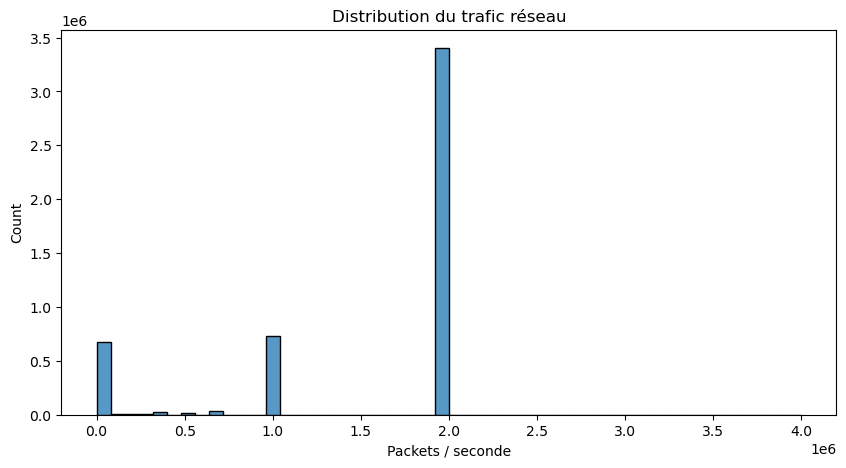

In [12]:
"""
VISUALISATION DES DISTRIBUTIONS

Nous analysons la distribution du nombre de
paquets par seconde.
"""

plt.figure(figsize=(10,5))

sns.histplot(df["Flow Packets/s"], bins=50)

plt.title("Distribution du trafic réseau")
plt.xlabel("Packets / seconde")

plt.show()

In [13]:
"""
ANALYSE PAR TYPE DE TRAFIC

Le dataset contient deux types de trafic :

BENIGN     : trafic normal
DrDoS_DNS  : trafic d'attaque
"""

print(df["Label"].value_counts())

Label
DrDoS_DNS    4908665
BENIGN          3354
Name: count, dtype: int64


In [14]:
"""
DÉTECTION D'ANOMALIES STATISTIQUE

Nous utilisons la règle :

seuil = moyenne + 3 × écart type

Cette méthode est souvent utilisée pour
la détection rapide d'anomalies réseau.
"""

threshold = df["Flow Packets/s"].mean() + 3 * df["Flow Packets/s"].std()

df["Anomaly"] = df["Flow Packets/s"] > threshold

print("Flux suspects détectés :", df["Anomaly"].sum())

Flux suspects détectés : 1


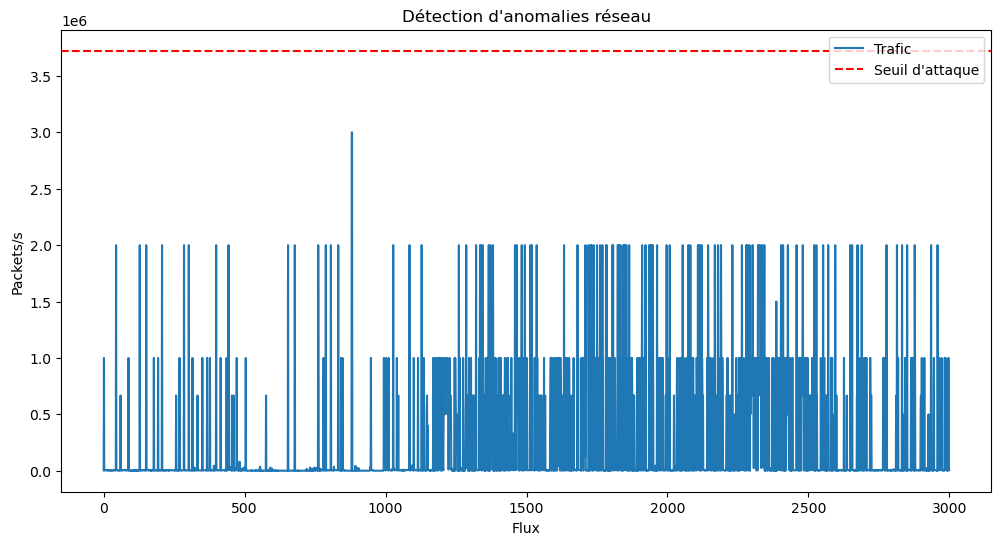

In [15]:
"""
VISUALISATION DU TRAFIC

Nous visualisons les flux réseau et le seuil
de détection des attaques.
"""

plt.figure(figsize=(12,6))

plt.plot(df["Flow Packets/s"].values[:3000], label="Trafic")

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label="Seuil d'attaque"
)

plt.title("Détection d'anomalies réseau")
plt.xlabel("Flux")
plt.ylabel("Packets/s")

plt.legend()

plt.show()

In [16]:
"""
IDENTIFICATION DES IP ATTAQUANTES

Les attaques DDoS proviennent souvent
d'un grand nombre d'IP sources.
"""

top_attackers = (
    df.groupby("Source IP")["Flow Packets/s"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_attackers

Source IP
204.154.111.111    2.250000e+06
172.217.197.155    2.000000e+06
204.154.111.114    2.000000e+06
204.154.111.108    2.000000e+06
173.241.244.143    2.000000e+06
172.217.3.98       2.000000e+06
172.217.1.4        2.000000e+06
8.8.8.8            2.000000e+06
204.154.111.134    1.750000e+06
4.2.2.4            1.666667e+06
Name: Flow Packets/s, dtype: float64

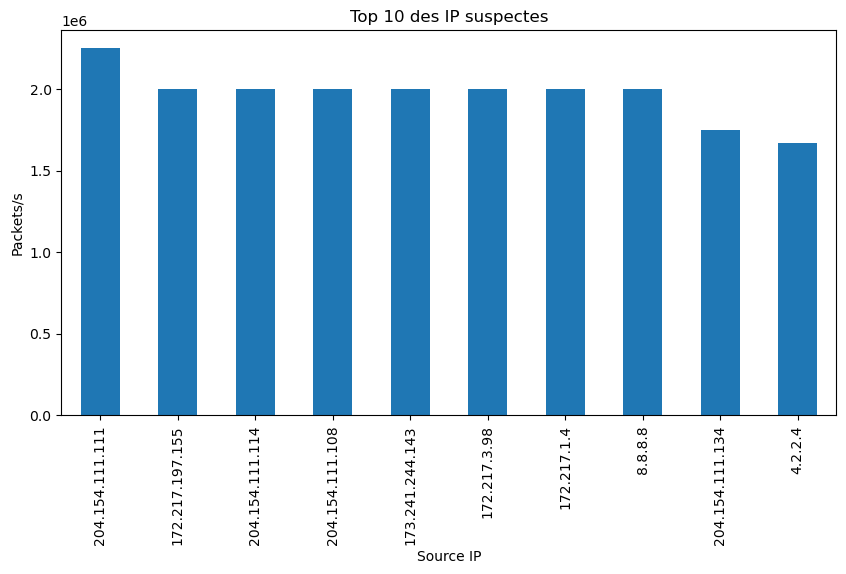

In [17]:
"""
VISUALISATION DES IP LES PLUS ACTIVES
"""

plt.figure(figsize=(10,5))

top_attackers.plot(kind="bar")

plt.title("Top 10 des IP suspectes")

plt.ylabel("Packets/s")

plt.show()

In [18]:
"""
DÉTECTION AVEC MACHINE LEARNING

Nous utilisons l'algorithme Isolation Forest
qui est adapté pour la détection d'anomalies.

Il identifie les observations rares
dans un dataset.
"""

model = IsolationForest(
    contamination=0.01,
    random_state=42
)

model.fit(df_features)

df["ML_Anomaly"] = model.predict(df_features)

df["ML_Anomaly"].value_counts()

ML_Anomaly
 1    4863325
-1      48694
Name: count, dtype: int64

In [19]:
"""
COMPARAISON DES MÉTHODES

Nous comparons la détection statistique
avec la détection par machine learning.
"""

pd.crosstab(df["ML_Anomaly"], df["Label"])

Label,BENIGN,DrDoS_DNS
ML_Anomaly,,
-1,2899,45795
1,455,4862870


In [20]:
"""
GÉNÉRATION AUTOMATIQUE D'UN RAPPORT
"""

report = f"""
===============================
RAPPORT DE CYBERSÉCURITÉ
Analyse DrDoS DNS
===============================

Dataset : CIC-DDoS2019

Nombre total de flux analysés : {len(df)}

Variables analysées :
Flow Duration
Total Fwd Packets
Total Backward Packets
Flow Bytes/s
Flow Packets/s

Méthodes de détection utilisées :

1. Détection statistique (seuil μ + 3σ)
2. Machine Learning (Isolation Forest)

Seuil statistique :
{threshold:.2f} packets/s

Flux suspects détectés :
{df['Anomaly'].sum()}

Conclusion :

L'analyse des logs réseau montre que les attaques
DrDoS DNS génèrent une augmentation importante
du nombre de paquets par seconde.

Les résultats démontrent qu'une analyse statistique
combinée à des techniques de machine learning
permet de détecter efficacement des attaques
DDoS dans les infrastructures réseau modernes.

Cette approche peut être intégrée dans des
architectures de cybersécurité autonomes
pour les réseaux 6G et les environnements SDN.
"""

print(report)


RAPPORT DE CYBERSÉCURITÉ
Analyse DrDoS DNS

Dataset : CIC-DDoS2019

Nombre total de flux analysés : 4912019

Variables analysées :
Flow Duration
Total Fwd Packets
Total Backward Packets
Flow Bytes/s
Flow Packets/s

Méthodes de détection utilisées :

1. Détection statistique (seuil μ + 3σ)
2. Machine Learning (Isolation Forest)

Seuil statistique :
3724034.46 packets/s

Flux suspects détectés :
1

Conclusion :

L'analyse des logs réseau montre que les attaques
DrDoS DNS génèrent une augmentation importante
du nombre de paquets par seconde.

Les résultats démontrent qu'une analyse statistique
combinée à des techniques de machine learning
permet de détecter efficacement des attaques
DDoS dans les infrastructures réseau modernes.

Cette approche peut être intégrée dans des
architectures de cybersécurité autonomes
pour les réseaux 6G et les environnements SDN.



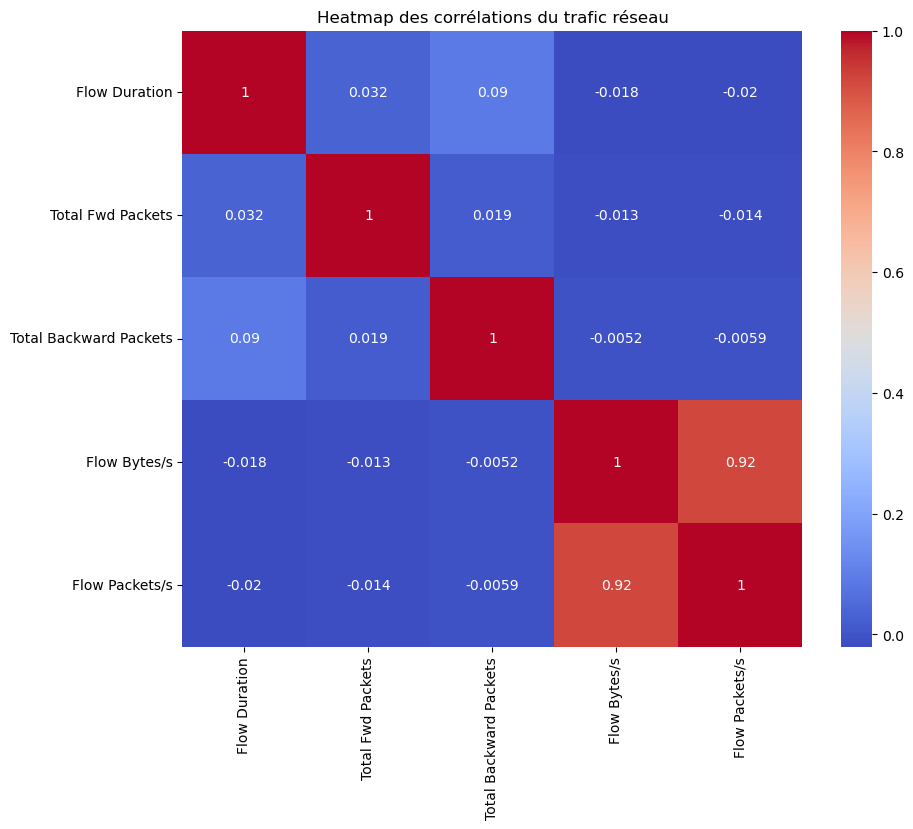

In [21]:
"""
HEATMAP DES CORRÉLATIONS

Cette analyse permet d'identifier les relations entre
les différentes variables du trafic réseau.

Une forte corrélation entre certaines variables peut
indiquer des comportements caractéristiques des attaques.
"""

plt.figure(figsize=(10,8))

correlation_matrix = df_features.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Heatmap des corrélations du trafic réseau")

plt.show()

In [22]:
"""
ANALYSE TEMPORELLE DU TRAFIC

Nous analysons l'évolution du trafic dans le temps
afin d'identifier les périodes d'attaques.
"""

# conversion du timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

df = df.dropna(subset=["Timestamp"])

In [23]:
"""
AGRÉGATION DU TRAFIC

Nous calculons le trafic moyen par minute.
"""

traffic_time = df.resample(
    "1Min",
    on="Timestamp"
)["Flow Packets/s"].mean()

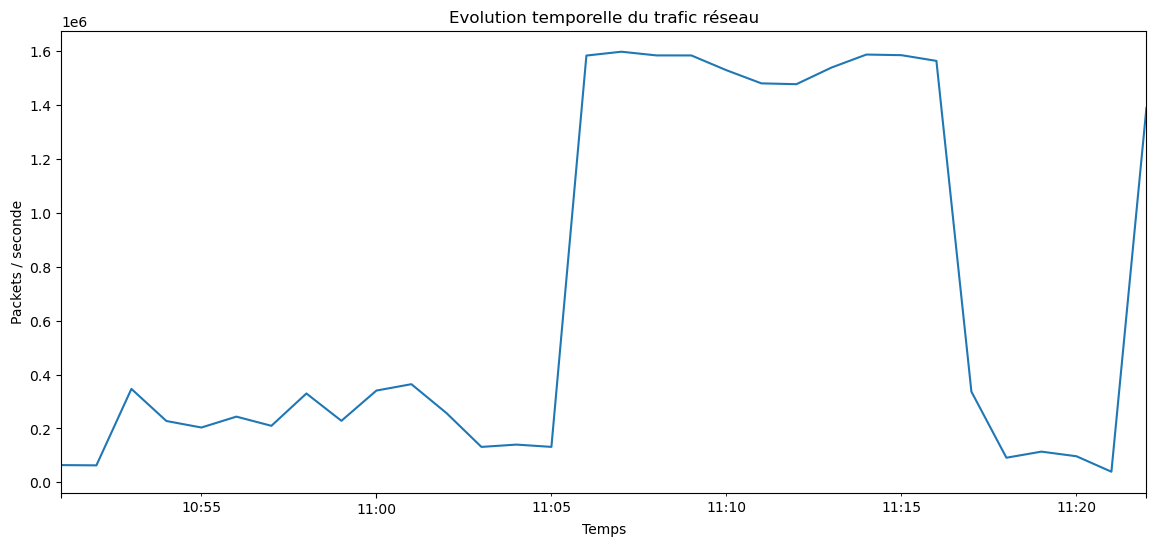

In [24]:
plt.figure(figsize=(14,6))

traffic_time.plot()

plt.title("Evolution temporelle du trafic réseau")

plt.xlabel("Temps")

plt.ylabel("Packets / seconde")

plt.show()

In [25]:
"""
STATISTIQUES DE SÉCURITÉ

Ce tableau de bord présente les indicateurs
principaux de cybersécurité du réseau.
"""

total_flows = len(df)

total_attacks = df[df["Label"] != "BENIGN"].shape[0]

attack_percentage = (total_attacks / total_flows) * 100

unique_ips = df["Source IP"].nunique()

print("===== DASHBOARD CYBERSECURITE =====")

print("Nombre total de flux :", total_flows)

print("Nombre d'attaques détectées :", total_attacks)

print("Pourcentage d'attaques :", round(attack_percentage,2), "%")

print("Nombre d'IP sources :", unique_ips)

===== DASHBOARD CYBERSECURITE =====
Nombre total de flux : 4912019
Nombre d'attaques détectées : 4908665
Pourcentage d'attaques : 99.93 %
Nombre d'IP sources : 136


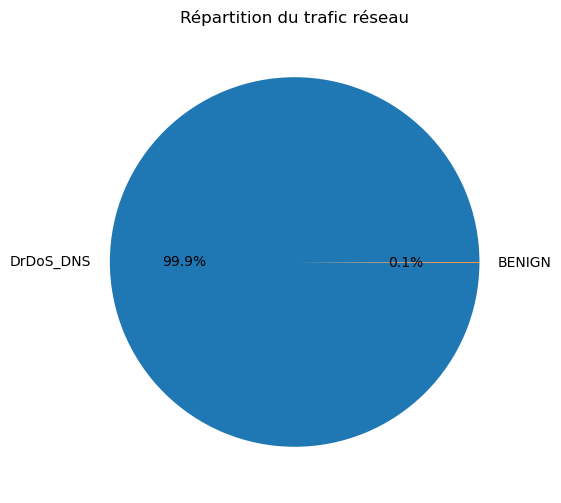

In [26]:
plt.figure(figsize=(6,6))

df["Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Répartition du trafic réseau")

plt.ylabel("")

plt.show()

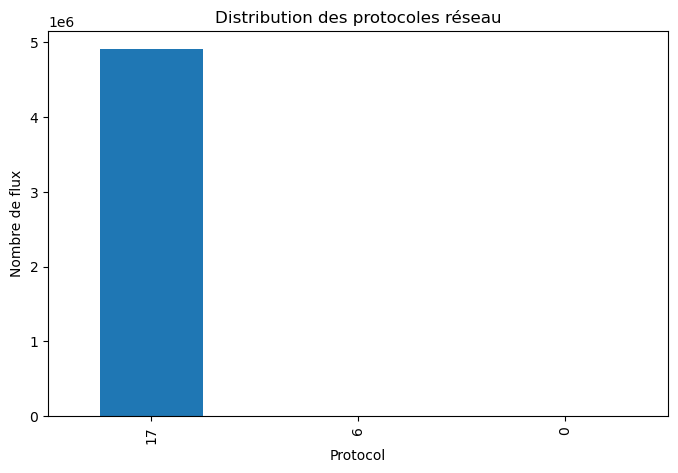

In [27]:
"""
ANALYSE PAR PROTOCOLE
"""

plt.figure(figsize=(8,5))

df["Protocol"].value_counts().plot(kind="bar")

plt.title("Distribution des protocoles réseau")

plt.xlabel("Protocol")

plt.ylabel("Nombre de flux")

plt.show()

In [28]:
"""
CALCUL DU SCORE DE RISQUE DES IP

Chaque IP reçoit un score basé sur :
- nombre de flux
- trafic moyen
- nombre d'anomalies détectées
"""

ip_stats = df.groupby("Source IP").agg(
    total_flows=("Source IP","count"),
    avg_packets=("Flow Packets/s","mean"),
    anomalies=("Anomaly","sum")
)

# normalisation du score
ip_stats["risk_score"] = (
    ip_stats["avg_packets"] * 0.6 +
    ip_stats["anomalies"] * 0.4
)

# tri des IP les plus suspectes
ip_stats = ip_stats.sort_values("risk_score", ascending=False)

ip_stats.head(10)

,total_flows,avg_packets,anomalies,risk_score
Source IP,,,,
204.154.111.111,4,2.250000e+06,0,1350000.0
172.217.197.155,1,2.000000e+06,0,1200000.0
204.154.111.114,3,2.000000e+06,0,1200000.0
204.154.111.108,1,2.000000e+06,0,1200000.0
173.241.244.143,1,2.000000e+06,0,1200000.0
172.217.3.98,2,2.000000e+06,0,1200000.0
172.217.1.4,1,2.000000e+06,0,1200000.0
8.8.8.8,1,2.000000e+06,0,1200000.0
204.154.111.134,4,1.750000e+06,0,1050000.0


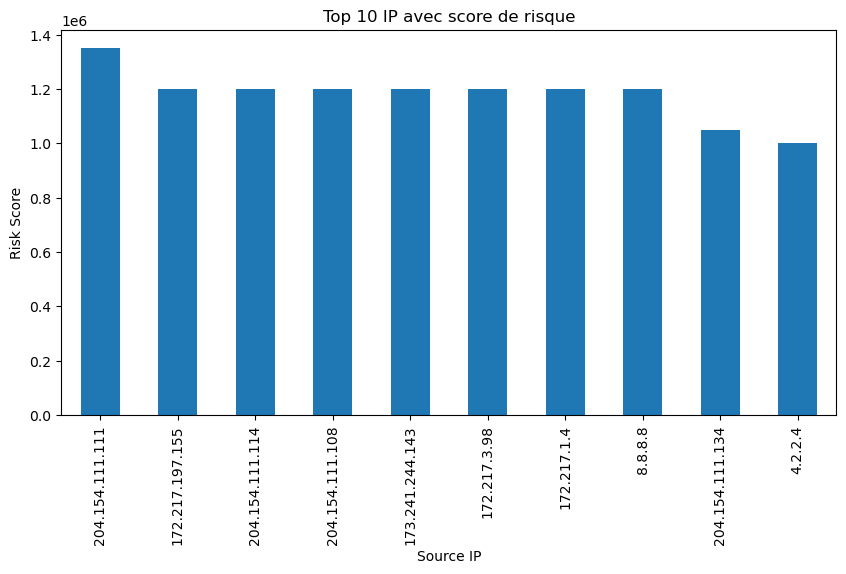

In [29]:
plt.figure(figsize=(10,5))

ip_stats["risk_score"].head(10).plot(kind="bar")

plt.title("Top 10 IP avec score de risque")

plt.ylabel("Risk Score")

plt.show()

In [31]:
"""
GRAPH DES COMMUNICATIONS RÉSEAU

Chaque noeud = IP
Chaque lien = communication réseau
"""

import networkx as nx

G = nx.from_pandas_edgelist(
    df.sample(2000),
    source="Source IP",
    target="Destination IP"
)

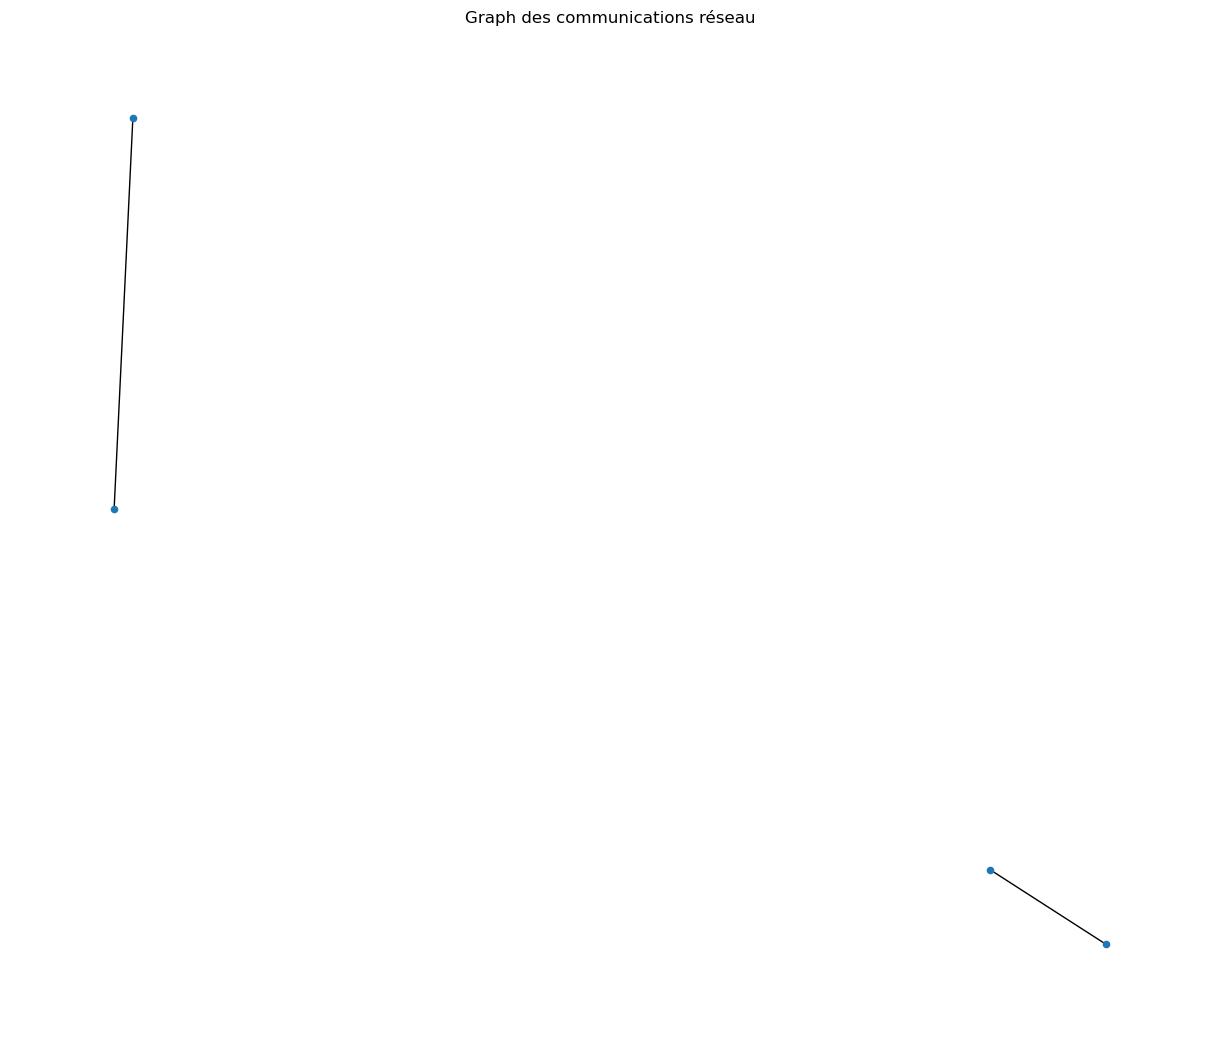

In [32]:
plt.figure(figsize=(12,10))

nx.draw(
    G,
    node_size=20,
    with_labels=False
)

plt.title("Graph des communications réseau")

plt.show()

In [34]:
from fpdf import FPDF

"""
GÉNÉRATION DU RAPPORT PDF
"""

pdf = FPDF()

pdf.add_page()

pdf.set_font("Arial", size=12)

pdf.cell(200,10,"Cybersecurity Analysis Report", ln=True)

pdf.cell(200,10,"Dataset : CIC-DDoS2019 (DrDoS DNS)", ln=True)

pdf.cell(200,10,f"Total flows analysed : {len(df)}", ln=True)

pdf.cell(200,10,f"Detected anomalies : {df['Anomaly'].sum()}", ln=True)

pdf.cell(200,10,f"Attack percentage : {round(attack_percentage,2)}%", ln=True)

pdf.cell(200,10,"Top suspicious IP :", ln=True)

for ip in ip_stats.head(5).index:
    pdf.cell(200,10,str(ip), ln=True)

pdf.output("cybersecurity_report.pdf")

print("Rapport PDF généré")

Rapport PDF généré


In [35]:
"""
DETECTION DE BOTNET

Les botnets sont caractérisés par :
- plusieurs IP
- envoyant un trafic très élevé
- vers des cibles communes
"""

botnet_analysis = df.groupby("Source IP").agg(
    total_packets=("Flow Packets/s","sum"),
    avg_packets=("Flow Packets/s","mean"),
    total_flows=("Source IP","count")
)

botnet_analysis = botnet_analysis.sort_values(
    "total_packets",
    ascending=False
)

botnet_analysis.head(10)

,total_packets,avg_packets,total_flows
Source IP,,,
172.16.0.5,7.606298e+12,1.550154e+06,4906800
192.168.50.1,1.913046e+09,1.019204e+06,1877
192.168.50.6,1.936856e+08,1.655433e+05,1170
192.168.50.8,1.728778e+08,1.975746e+05,875
192.168.50.7,4.797976e+07,9.156442e+04,524
192.168.50.253,4.537136e+07,5.892384e+05,77
192.168.50.254,4.441429e+07,6.084149e+05,73
8.6.0.1,3.671945e+07,1.049127e+06,35
74.208.236.171,3.117335e+07,4.270322e+05,73


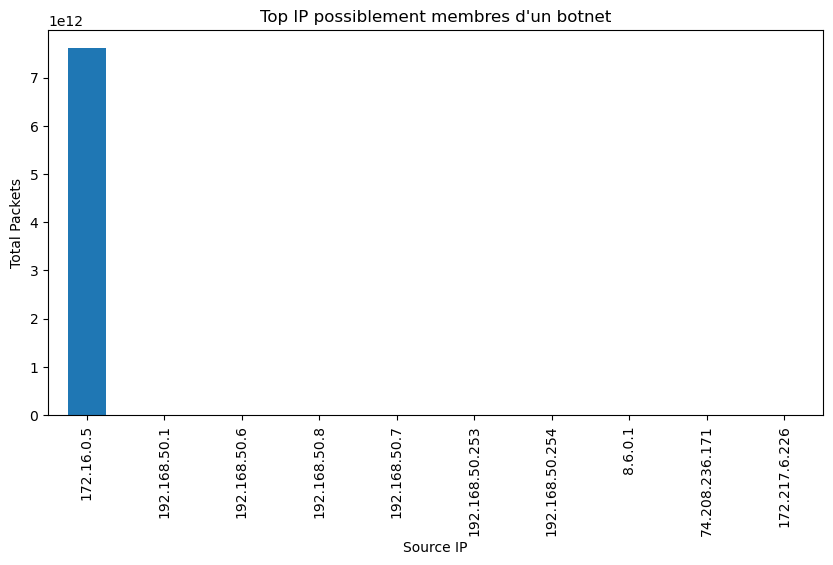

In [36]:
plt.figure(figsize=(10,5))

botnet_analysis["total_packets"].head(10).plot(kind="bar")

plt.title("Top IP possiblement membres d'un botnet")

plt.ylabel("Total Packets")

plt.show()

In [37]:
"""
PREPARATION DU DATASET POUR LE MACHINE LEARNING
"""

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Label_encoded"] = encoder.fit_transform(df["Label"])

X = df_features

y = df["Label_encoded"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       994
           1       1.00      1.00      1.00   1472612

    accuracy                           1.00   1473606
   macro avg       0.96      0.98      0.97   1473606
weighted avg       1.00      1.00      1.00   1473606



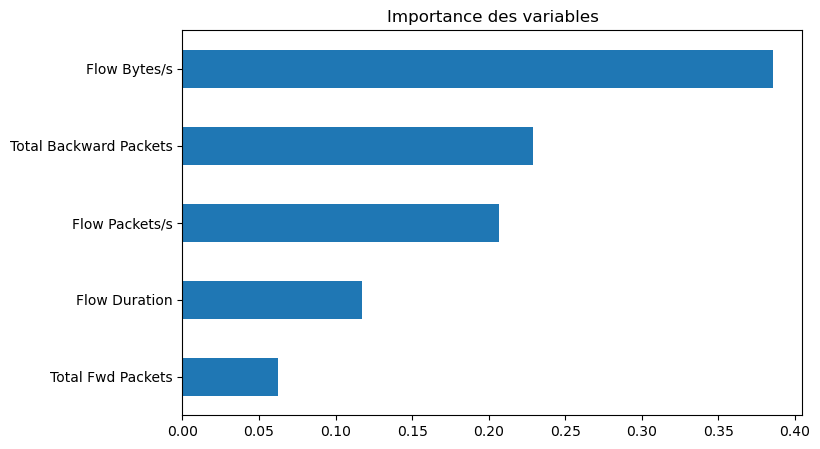

In [45]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Importance des variables")

plt.show()

In [46]:
"""
SIMULATION D'UNE ARCHITECTURE DISTRIBUEE

Chaque capteur surveille une partie du réseau.
"""

num_sensors = 4

df["sensor_id"] = np.random.randint(
    1,
    num_sensors+1,
    size=len(df)
)

In [47]:
sensor_stats = df.groupby("sensor_id").agg(
    flows=("sensor_id","count"),
    anomalies=("Anomaly","sum"),
    attacks=("Label_encoded","sum")
)

sensor_stats

,flows,anomalies,attacks
sensor_id,,,
1,1228233,1,1227342
2,1228365,0,1227557
3,1226514,0,1225708
4,1228907,0,1228058


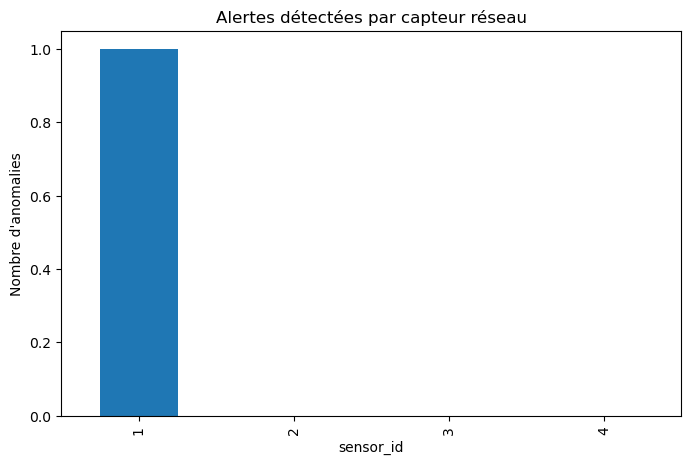

In [48]:
plt.figure(figsize=(8,5))

sensor_stats["anomalies"].plot(
    kind="bar"
)

plt.title("Alertes détectées par capteur réseau")

plt.ylabel("Nombre d'anomalies")

plt.show()